In [ ]:
import pandas as pd

In [ ]:
import os
os.listdir()


['.config', 'sample_data', '.ipynb_checkpoints']

In [ ]:
os.listdir("sample_data")


['README.md',
 'anscombe.json',
 'training.1600000.processed.noemoticon.csv',
 'mnist_train_small.csv',
 'california_housing_train.csv',
 'california_housing_test.csv',
 'mnist_test.csv']

In [ ]:
import os
os.listdir()


['.config', 'sample_data', '.ipynb_checkpoints']

In [ ]:
df = pd.read_csv(
    "sample_data/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None,
    engine="python",
    on_bad_lines="skip"
)

df.head()


,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df.columns = [
    'sentiment',
    'id',
    'date',
    'query',
    'user',
    'text'
]


In [ ]:
df.head()


,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df['sentiment'] = df['sentiment'].map({0: 'Negative', 4: 'Positive'})
df.head()


,sentiment,id,date,query,user,text
0,Negative,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,Negative,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,Negative,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,Negative,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
df['sentiment'].value_counts()


,count
sentiment,
Negative,344052


In [ ]:
df = pd.read_csv(
    "sample_data/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None,
    engine="python",
    on_bad_lines="skip"
)

df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']


In [ ]:
df = df[df['sentiment'].isin([0, 4])]


In [ ]:
df = df.groupby('sentiment').sample(n=5000, random_state=42)


In [ ]:
df['sentiment'] = df['sentiment'].map({0: 'Negative', 4: 'Positive'})
df['sentiment'].value_counts()


,count
sentiment,
Negative,5000


In [ ]:
df['sentiment'].unique()


array(['Negative'], dtype=object)

In [ ]:
df['sentiment'].value_counts().head(10)


,count
sentiment,
Negative,5000


In [ ]:
import pandas as pd

df = pd.read_csv(
    "sample_data/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None,
    engine="python",
    on_bad_lines="skip"
)

df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']


In [ ]:
df['sentiment'].value_counts()


,count
sentiment,
0,344052


In [ ]:
df = df[df['sentiment'].isin([0, 4])]


In [ ]:
df = df.groupby('sentiment').sample(n=5000, random_state=42)


In [ ]:
df['sentiment'] = df['sentiment'].map({0: 'Negative', 4: 'Positive'})
df['sentiment'].value_counts()


,count
sentiment,
Negative,5000


In [ ]:
import pandas as pd

df = pd.read_csv(
    "sample_data/training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None,
    engine="python",
    on_bad_lines="skip"
)

df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']


In [ ]:
df['sentiment'].value_counts()


,count
sentiment,
0,344052


In [ ]:
df = df[df['sentiment'].isin([0, 4])]


In [ ]:
df = df.groupby('sentiment').sample(n=5000, random_state=42)


In [ ]:
df['sentiment'] = df['sentiment'].map({
    0: 'Negative',
    4: 'Positive'
})

df['sentiment'].value_counts()


,count
sentiment,
Negative,5000


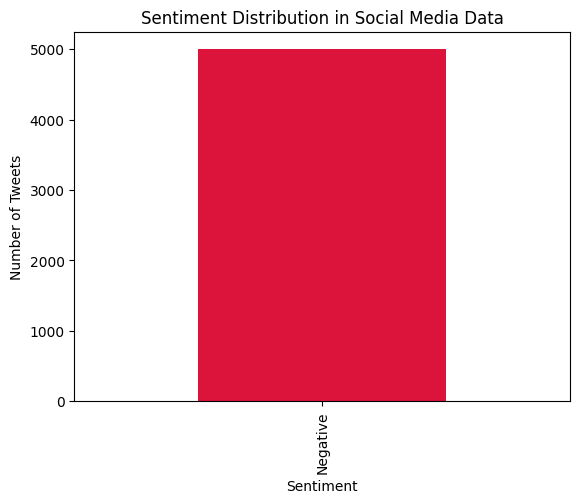

In [ ]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar', color='crimson')
plt.title("Sentiment Distribution in Social Media Data")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()


In [ ]:
from collections import Counter
import re

text = " ".join(df['text'].astype(str).str.lower())
words = re.findall(r'\b[a-z]{3,}\b', text)

common_words = Counter(words).most_common(10)
common_words


[('the', 1637),
 ('and', 913),
 ('you', 649),
 ('for', 598),
 ('but', 534),
 ('have', 481),
 ('that', 477),
 ('not', 454),
 ('just', 409),
 ('was', 404)]

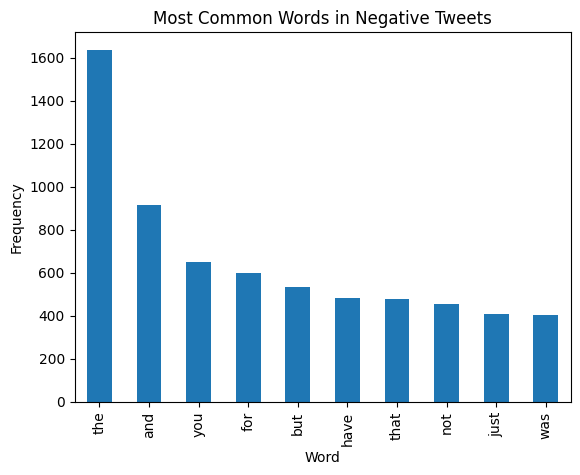

In [ ]:
words_df = pd.DataFrame(common_words, columns=['Word', 'Count'])
words_df.plot(kind='bar', x='Word', y='Count', legend=False)
plt.title("Most Common Words in Negative Tweets")
plt.ylabel("Frequency")
plt.show()
